# 📊 Visual Guide: Bit Tricks → Wave Functions

**A matplotlib companion to the terminal scripts.**

Each section below corresponds to one of the 6 scripts in this repo, turning the ASCII art into real plots you can zoom, save, and explore. Run cells sequentially — later sections build on earlier ones.

| Section | Script | Core Idea |
|---------|--------|-----------|
| 1 | `signals_and_sampling.py` | Sampling, aliasing, quantization |
| 2 | `fourier_transform.py` | DFT, FFT, spectral analysis |
| 3 | `wavelets_and_uncertainty.py` | Uncertainty principle, Haar wavelets |
| 4 | `practical_wave_applications.py` | DCT/JPEG, filters, spectrogram |
| 5 | `quantum_wave_functions.py` | Qubits, Grover's, entanglement |
| 6 | `the_full_spectrum.py` | Full pipeline: generate → reconstruct |

In [1]:
import numpy as np
import math, cmath
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.colors import LinearSegmentedColormap

# ── House style ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.alpha":       0.6,
    "figure.dpi":       120,
    "font.size":        9,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "legend.framealpha": 0.3,
    "legend.edgecolor":  "#30363d",
})

CYAN    = "#58a6ff"
GREEN   = "#3fb950"
ORANGE  = "#d29922"
RED     = "#f85149"
PURPLE  = "#bc8cff"
PINK    = "#f778ba"
COLORS  = [CYAN, GREEN, ORANGE, RED, PURPLE, PINK]

print("✓ Visual Guide ready — matplotlib", plt.matplotlib.__version__)

✓ Visual Guide ready — matplotlib 3.10.8


---
## 1 · Signals & Sampling
*Companion to `signals_and_sampling.py`*

> Any signal — no matter how complicated — can be written as a sum of sine waves.

### 1a — Superposition: building complex signals from simple ones

/tmp/ipykernel_2622/206599080.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


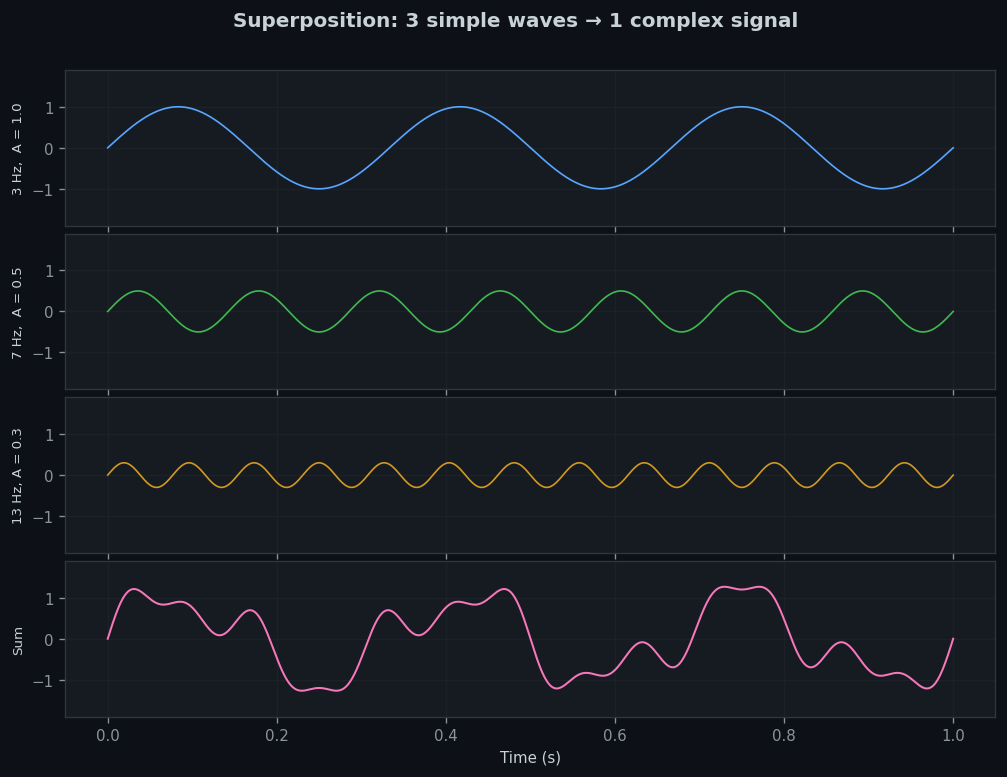

In [2]:
# ── 1a  Superposition ─────────────────────────────────────────
t = np.linspace(0, 1, 2000)
components = [
    (3,  1.0,  "3 Hz,  A = 1.0"),
    (7,  0.5,  "7 Hz,  A = 0.5"),
    (13, 0.3,  "13 Hz, A = 0.3"),
]

fig, axes = plt.subplots(len(components) + 1, 1, figsize=(10, 7),
                          sharex=True, gridspec_kw={"hspace": 0.05})
composite = np.zeros_like(t)
for ax, (freq, amp, label) in zip(axes[:-1], components):
    wave = amp * np.sin(2 * np.pi * freq * t)
    composite += wave
    ax.plot(t, wave, color=COLORS[components.index((freq, amp, label))],
            linewidth=1)
    ax.set_ylabel(label, fontsize=8)
    ax.set_ylim(-1.9, 1.9)
    ax.grid(True)
    ax.tick_params(labelbottom=False)

axes[-1].plot(t, composite, color=PINK, linewidth=1.2)
axes[-1].set_ylabel("Sum", fontsize=8)
axes[-1].set_xlabel("Time (s)")
axes[-1].set_ylim(-1.9, 1.9)
axes[-1].grid(True)

fig.suptitle("Superposition: 3 simple waves → 1 complex signal",
             y=0.95, fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 1b — Sampling & Aliasing

Sample a 10 Hz sine at rates **above** and **below** the Nyquist limit (2 × 10 = 20 Hz). Below Nyquist, the original frequency masquerades as a lower one — **aliasing**.

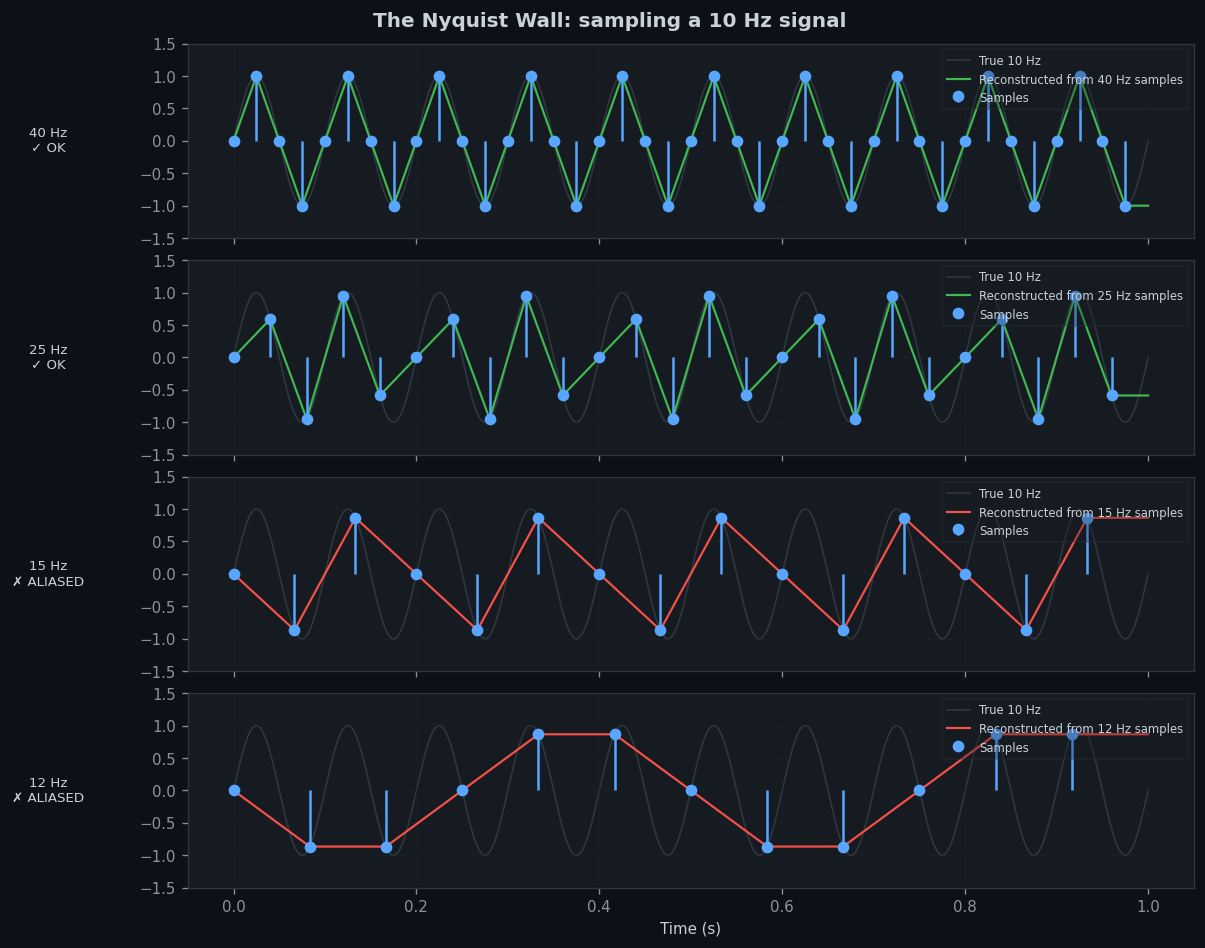

In [3]:
# ── 1b  Sampling & Aliasing ───────────────────────────────────
freq = 10
t_cont = np.linspace(0, 1, 5000)
signal_cont = np.sin(2 * np.pi * freq * t_cont)

sample_rates = [40, 25, 15, 12]
fig, axes = plt.subplots(len(sample_rates), 1, figsize=(10, 8), sharex=True)

for ax, sr in zip(axes, sample_rates):
    n_samp = int(sr)
    t_samp = np.arange(n_samp) / sr
    s_samp = np.sin(2 * np.pi * freq * t_samp)
    reconstructed = np.interp(t_cont, t_samp, s_samp)

    ax.plot(t_cont, signal_cont, color="#30363d", linewidth=1,
            label="True 10 Hz", zorder=1)
    ax.plot(t_cont, reconstructed, color=RED if sr < 20 else GREEN,
            linewidth=1.3, zorder=2,
            label=f"Reconstructed from {sr} Hz samples")
    ax.stem(t_samp, s_samp, linefmt=CYAN, markerfmt="o",
            basefmt=" ", label="Samples")
    ax.set_markersize = 3
    nyquist = "✓ OK" if sr >= 2 * freq else "✗ ALIASED"
    ax.set_ylabel(f"{sr} Hz\n{nyquist}", fontsize=8, rotation=0,
                  labelpad=55, va="center")
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=7)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("The Nyquist Wall: sampling a 10 Hz signal",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1c — Quantization: where bits meet waves

Sampling discretizes time; **quantization** discretizes amplitude. More bits = more levels = less error.

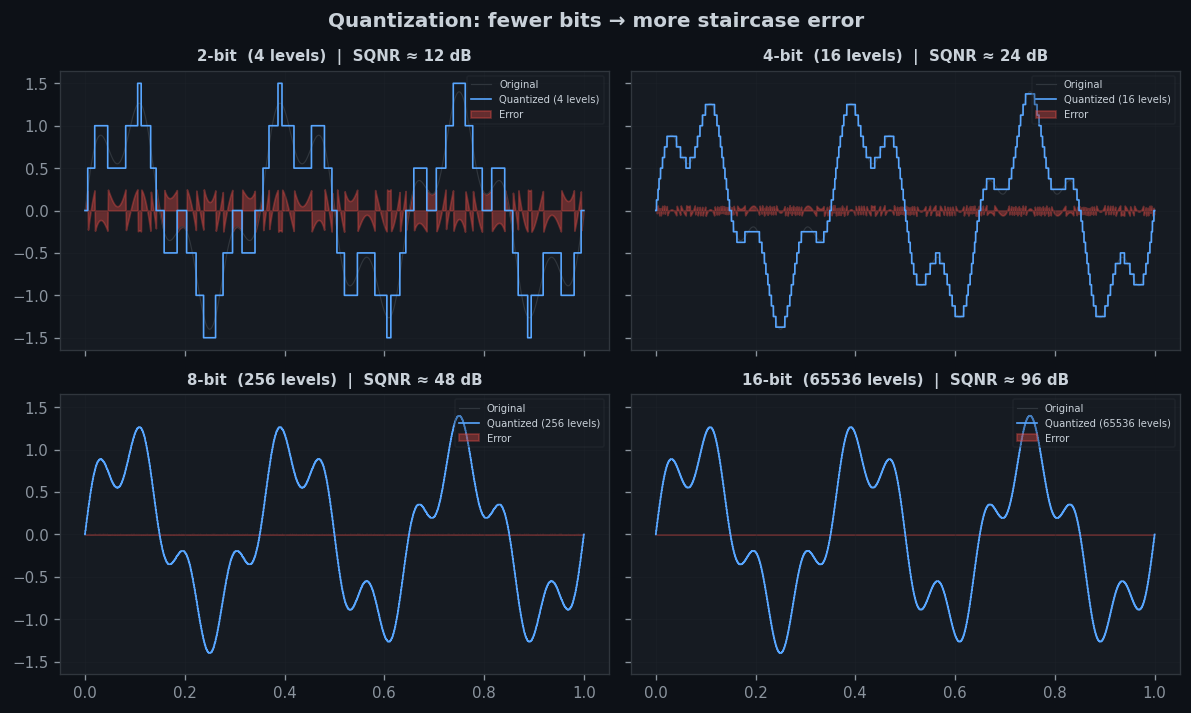

In [4]:
# ── 1c  Quantization ──────────────────────────────────────────
t = np.linspace(0, 1, 1000)
signal = np.sin(2 * np.pi * 3 * t) + 0.4 * np.sin(2 * np.pi * 11 * t)

bit_depths = [2, 4, 8, 16]
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

for ax, bits in zip(axes.flat, bit_depths):
    levels = 2 ** bits
    step = 2.0 / levels          # signal range ≈ [-1, 1]
    quantized = np.round(signal / step) * step
    error = signal - quantized

    ax.plot(t, signal, color="#30363d", linewidth=0.7, label="Original")
    ax.step(t, quantized, where="mid", color=CYAN, linewidth=1,
            label=f"Quantized ({levels} levels)")
    ax.fill_between(t, 0, error, color=RED, alpha=0.35, label="Error")
    ax.set_title(f"{bits}-bit  ({levels} levels)  |  SQNR ≈ {6.02*bits:.0f} dB",
                 fontsize=9)
    ax.legend(fontsize=6, loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle("Quantization: fewer bits → more staircase error",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2 · The Fourier Transform
*Companion to `fourier_transform.py`*

### 2a — Euler's Formula: the Rosetta Stone

$e^{i\theta} = \cos\theta + i\sin\theta$ — an exponential **is** a wave spinning in the complex plane.

/tmp/ipykernel_2622/1579440571.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


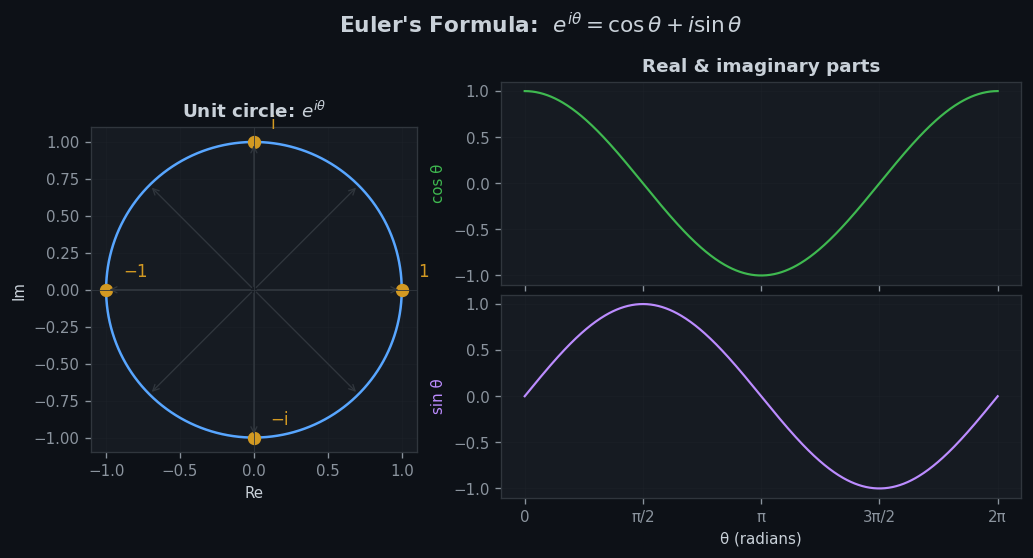

In [5]:
# ── 2a  Euler's formula ───────────────────────────────────────
theta = np.linspace(0, 2 * np.pi, 500)
z = np.exp(1j * theta)

fig = plt.figure(figsize=(10, 4.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.6], hspace=0.05)

# Left: unit circle
ax_circle = fig.add_subplot(gs[:, 0], aspect="equal")
ax_circle.plot(z.real, z.imag, color=CYAN, linewidth=1.5)
# Mark a few key angles
for k, label in [(0, "1"), (1, "i"), (2, "−1"), (3, "−i")]:
    angle = k * np.pi / 2
    pt = np.exp(1j * angle)
    ax_circle.plot(pt.real, pt.imag, "o", color=ORANGE, markersize=7)
    ax_circle.annotate(label, (pt.real, pt.imag), fontsize=10,
                       textcoords="offset points", xytext=(10, 8),
                       color=ORANGE)
# Sweeping arrow
for k in range(0, 8):
    angle = k * np.pi / 4
    pt = np.exp(1j * angle)
    ax_circle.annotate("", xy=(pt.real, pt.imag), xytext=(0, 0),
                       arrowprops=dict(arrowstyle="->", color="#30363d",
                                       lw=0.8))
ax_circle.axhline(0, color="#30363d", lw=0.5)
ax_circle.axvline(0, color="#30363d", lw=0.5)
ax_circle.set_title("Unit circle: $e^{i\\theta}$")
ax_circle.set_xlabel("Re")
ax_circle.set_ylabel("Im")
ax_circle.grid(True, alpha=0.3)

# Right top: cos(θ)
ax_re = fig.add_subplot(gs[0, 1])
ax_re.plot(theta, z.real, color=GREEN, linewidth=1.3)
ax_re.set_ylabel("cos θ", color=GREEN)
ax_re.set_title("Real & imaginary parts")
ax_re.grid(True, alpha=0.3)
ax_re.tick_params(labelbottom=False)

# Right bottom: sin(θ)
ax_im = fig.add_subplot(gs[1, 1], sharex=ax_re)
ax_im.plot(theta, z.imag, color=PURPLE, linewidth=1.3)
ax_im.set_ylabel("sin θ", color=PURPLE)
ax_im.set_xlabel("θ (radians)")
ax_im.grid(True, alpha=0.3)
ax_im.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_im.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])

fig.suptitle("Euler's Formula:  $e^{i\\theta} = \\cos\\theta + i\\sin\\theta$",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 2b — DFT in action: time domain → frequency domain

The DFT correlates each frequency "test wave" against the signal. Peaks in the magnitude spectrum reveal the component frequencies.

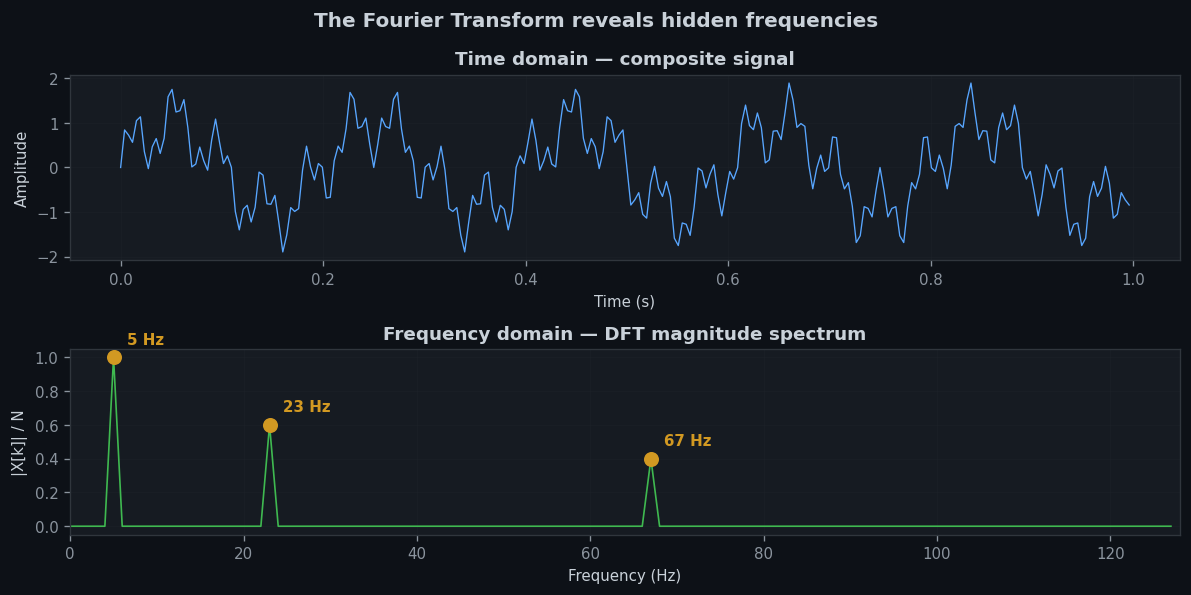

In [6]:
# ── 2b  DFT spectral analysis ─────────────────────────────────
N = 256
fs = 256
t = np.arange(N) / fs
freqs_true = [(5, 1.0), (23, 0.6), (67, 0.4)]   # (Hz, amplitude)
signal = sum(a * np.sin(2 * np.pi * f * t) for f, a in freqs_true)

# Compute DFT (using numpy's FFT)
X = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, 1 / fs)
magnitude = np.abs(X) / N * 2   # normalize

fig, (ax_time, ax_freq) = plt.subplots(2, 1, figsize=(10, 5))

ax_time.plot(t, signal, color=CYAN, linewidth=0.8)
ax_time.set_title("Time domain — composite signal")
ax_time.set_xlabel("Time (s)")
ax_time.set_ylabel("Amplitude")
ax_time.grid(True, alpha=0.3)

# Only plot positive frequencies
pos = freqs >= 0
ax_freq.plot(freqs[pos], magnitude[pos], color=GREEN, linewidth=1)
for f, a in freqs_true:
    idx = np.argmin(np.abs(freqs[pos] - f))
    ax_freq.plot(f, magnitude[pos][idx], "o", color=ORANGE, markersize=8,
                 zorder=5)
    ax_freq.annotate(f"{f} Hz", (f, magnitude[pos][idx]),
                     textcoords="offset points", xytext=(8, 8),
                     fontsize=9, color=ORANGE, fontweight="bold")
ax_freq.set_title("Frequency domain — DFT magnitude spectrum")
ax_freq.set_xlabel("Frequency (Hz)")
ax_freq.set_ylabel("|X[k]| / N")
ax_freq.set_xlim(0, fs / 2)
ax_freq.grid(True, alpha=0.3)

fig.suptitle("The Fourier Transform reveals hidden frequencies",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 2c — Windowing & spectral leakage

When a signal doesn't fit an exact integer number of cycles in the analysis window, energy "leaks" to neighboring frequency bins. Applying a window function tapers the edges and suppresses leakage.

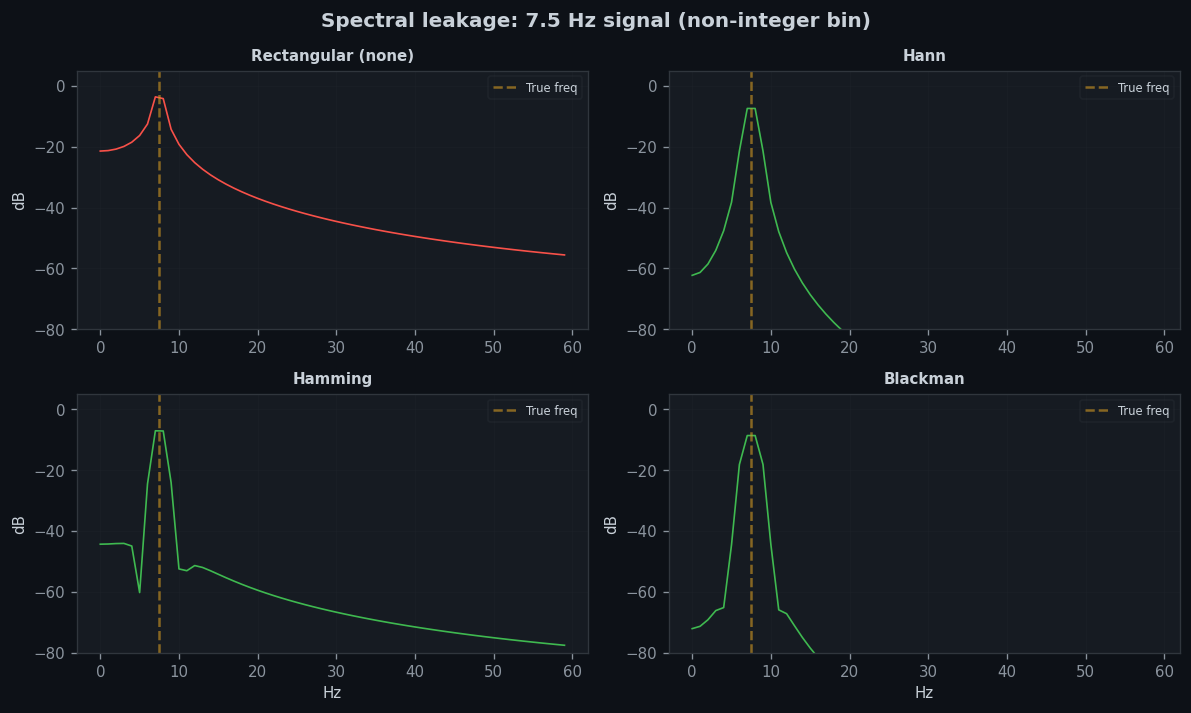

In [7]:
# ── 2c  Windowing ─────────────────────────────────────────────
N = 256
fs = 256
t = np.arange(N) / fs
# 7.5 Hz — NOT an integer bin → leakage
signal = np.sin(2 * np.pi * 7.5 * t)

windows = {
    "Rectangular (none)": np.ones(N),
    "Hann":               0.5 * (1 - np.cos(2 * np.pi * np.arange(N) / N)),
    "Hamming":            0.54 - 0.46 * np.cos(2 * np.pi * np.arange(N) / N),
    "Blackman":           (0.42 - 0.5 * np.cos(2*np.pi*np.arange(N)/N)
                           + 0.08 * np.cos(4*np.pi*np.arange(N)/N)),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
freqs = np.fft.fftfreq(N, 1/fs)
pos = freqs >= 0

for ax, (name, w) in zip(axes.flat, windows.items()):
    windowed = signal * w
    X = np.fft.fft(windowed)
    mag_db = 20 * np.log10(np.abs(X[pos]) / N * 2 + 1e-12)
    color = RED if "Rect" in name else GREEN
    ax.plot(freqs[pos][:60], mag_db[:60], color=color, linewidth=1)
    ax.axvline(7.5, color=ORANGE, linestyle="--", alpha=0.6, label="True freq")
    ax.set_title(name, fontsize=9)
    ax.set_ylim(-80, 5)
    ax.set_ylabel("dB")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[1][0].set_xlabel("Hz")
axes[1][1].set_xlabel("Hz")
fig.suptitle("Spectral leakage: 7.5 Hz signal (non-integer bin)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3 · Wavelets & the Uncertainty Principle
*Companion to `wavelets_and_uncertainty.py`*

### 3a — Time–frequency uncertainty

A narrow pulse is localized in **time** but spread across all **frequencies**. A pure sine is localized in **frequency** but extends forever in **time**. You can't have both — Δt · Δf ≥ 1/(4π).

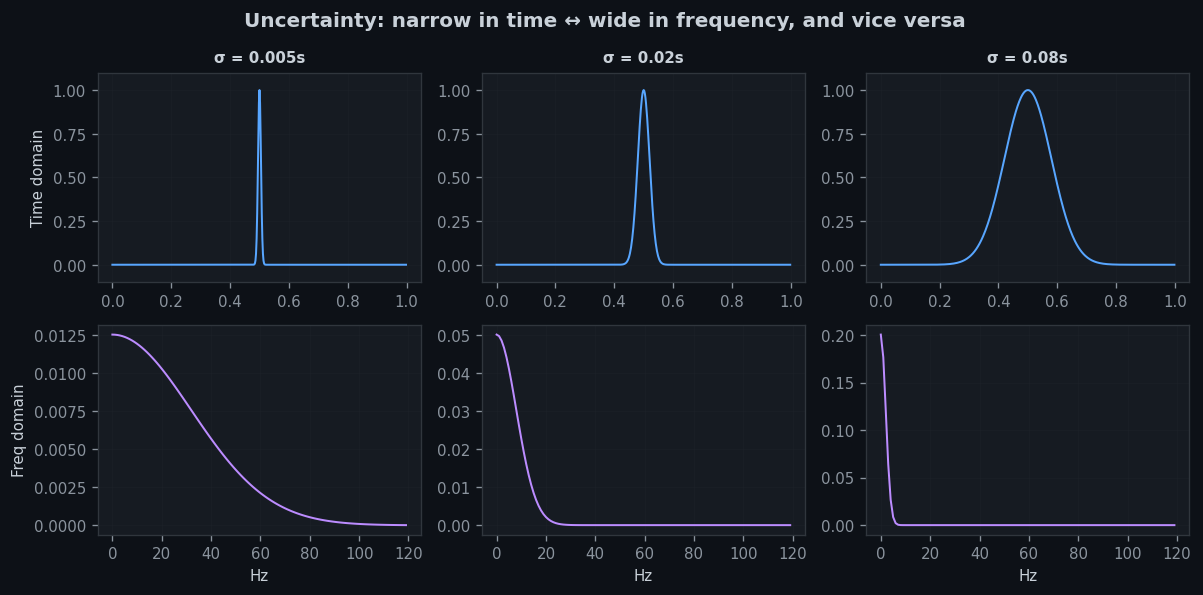

In [8]:
# ── 3a  Uncertainty principle ──────────────────────────────────
N = 512
fs = 512
t = np.arange(N) / fs
freqs = np.fft.fftfreq(N, 1/fs)
pos = freqs >= 0

# Three Gaussian pulses with different widths
sigmas = [0.005, 0.02, 0.08]
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

for col, sigma in enumerate(sigmas):
    # Gaussian pulse
    pulse = np.exp(-((t - 0.5) ** 2) / (2 * sigma**2))
    X = np.fft.fft(pulse)
    mag = np.abs(X[pos]) / N

    axes[0][col].plot(t, pulse, color=CYAN, linewidth=1.2)
    axes[0][col].set_title(f"σ = {sigma}s", fontsize=9)
    axes[0][col].set_ylim(-0.1, 1.1)
    axes[0][col].grid(True, alpha=0.3)
    if col == 0:
        axes[0][col].set_ylabel("Time domain")

    axes[1][col].plot(freqs[pos][:120], mag[:120], color=PURPLE, linewidth=1.2)
    axes[1][col].grid(True, alpha=0.3)
    if col == 0:
        axes[1][col].set_ylabel("Freq domain")
    axes[1][col].set_xlabel("Hz")

fig.suptitle("Uncertainty: narrow in time ↔ wide in frequency, and vice versa",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 3b — Haar wavelet multiresolution decomposition

The Haar wavelet recursively splits a signal into **approximation** (averages) and **detail** (differences) at each level. Coarse levels capture the trend; fine levels capture sharp edges.

/tmp/ipykernel_2622/1343153316.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


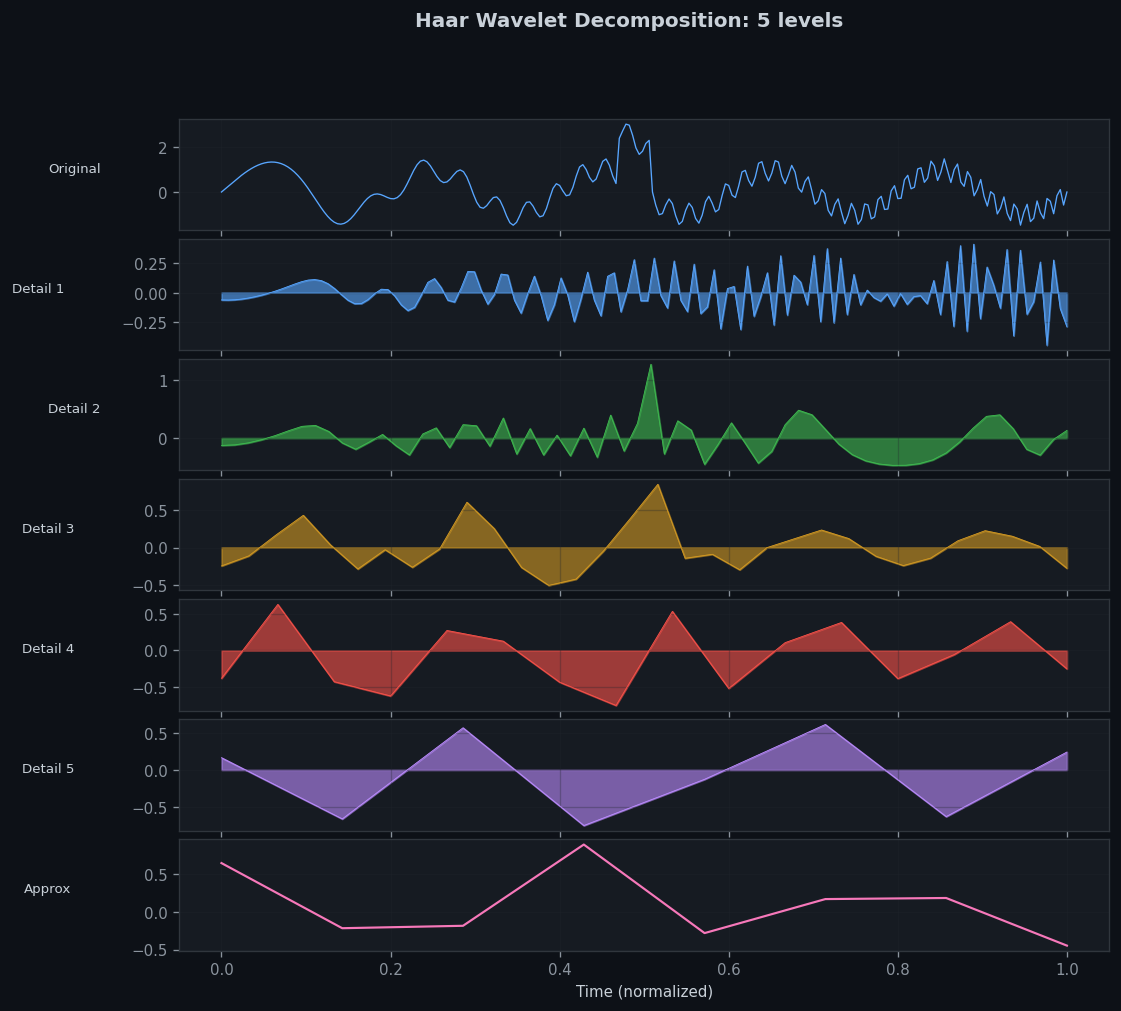

In [9]:
# ── 3b  Haar multiresolution ──────────────────────────────────
def haar_decompose(signal, max_levels=None):
    """Full Haar wavelet decomposition."""
    current = np.array(signal, dtype=float)
    details = []
    max_l = max_levels or int(math.log2(len(signal)))
    for _ in range(max_l):
        if len(current) < 2:
            break
        n = len(current) // 2 * 2
        approx = (current[:n:2] + current[1:n:2]) / 2
        detail = (current[:n:2] - current[1:n:2]) / 2
        details.append(detail)
        current = approx
    return current, details

def haar_reconstruct(approx, details):
    """Inverse Haar wavelet."""
    current = np.array(approx, dtype=float)
    for detail in reversed(details):
        n = min(len(current), len(detail))
        recon = np.empty(2 * n)
        recon[0::2] = current[:n] + detail[:n]
        recon[1::2] = current[:n] - detail[:n]
        current = recon
    return current

# A chirp signal with a sharp transient
N = 256
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 40 * t * t)
signal[120:130] += 2.0   # sharp spike

approx, details = haar_decompose(signal, max_levels=5)

fig, axes = plt.subplots(len(details) + 2, 1, figsize=(10, 9),
                          gridspec_kw={"hspace": 0.08})
axes[0].plot(t, signal, color=CYAN, linewidth=0.8)
axes[0].set_ylabel("Original", fontsize=8, rotation=0, labelpad=50)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelbottom=False)

for i, detail in enumerate(details):
    ax = axes[i + 1]
    t_d = np.linspace(0, 1, len(detail))
    ax.fill_between(t_d, 0, detail, color=COLORS[i % len(COLORS)], alpha=0.6)
    ax.plot(t_d, detail, color=COLORS[i % len(COLORS)], linewidth=0.5)
    ax.set_ylabel(f"Detail {i+1}", fontsize=8, rotation=0, labelpad=50)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False)

t_a = np.linspace(0, 1, len(approx))
axes[-1].plot(t_a, approx, color=PINK, linewidth=1.3)
axes[-1].set_ylabel("Approx", fontsize=8, rotation=0, labelpad=50)
axes[-1].set_xlabel("Time (normalized)")
axes[-1].grid(True, alpha=0.3)

fig.suptitle("Haar Wavelet Decomposition: 5 levels",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 3c — Wavelet denoising via soft thresholding

Noise lives primarily in the **detail** coefficients. By shrinking small details toward zero (soft thresholding) and reconstructing, we remove noise while preserving signal structure.

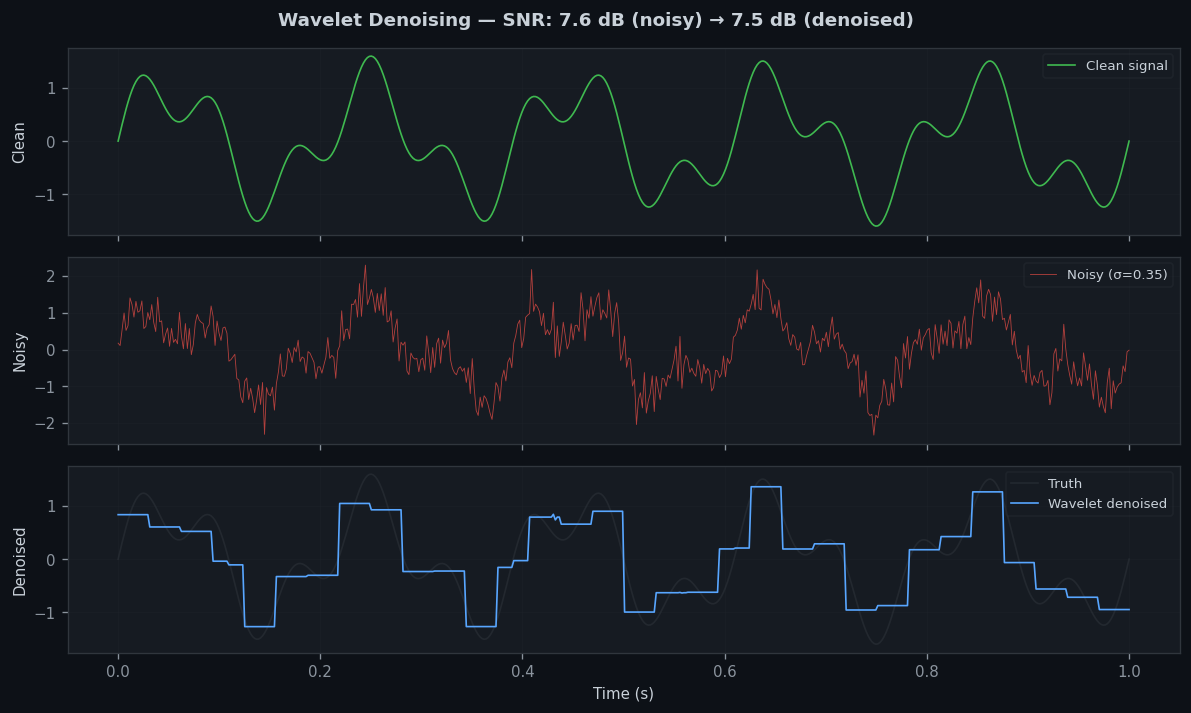

In [11]:
# ── 3c  Wavelet denoising ─────────────────────────────────────
def soft_threshold(coeffs, threshold):
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0)

N = 512
t = np.linspace(0, 1, N)
clean = np.sin(2 * np.pi * 5 * t) + 0.6 * np.sin(2 * np.pi * 13 * t)
np.random.seed(42)
noise_level = 0.35
noisy = clean + np.random.randn(N) * noise_level

approx, details = haar_decompose(noisy, max_levels=8)

# Threshold only the finest 4 detail levels (where noise dominates)
denoised_details = []
for i, d in enumerate(details):
    if i < 4:  # fine levels — threshold aggressively
        threshold = noise_level * math.sqrt(2 * math.log(max(len(d), 2))) * 0.6
        denoised_details.append(soft_threshold(d, threshold))
    else:       # coarse levels — keep as is (signal energy)
        denoised_details.append(d)

denoised = haar_reconstruct(approx, denoised_details)[:N]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, clean, color=GREEN, linewidth=1, label="Clean signal")
ax1.set_ylabel("Clean")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)

ax2.plot(t, noisy, color=RED, linewidth=0.5, alpha=0.7, label=f"Noisy (σ={noise_level})")
ax2.set_ylabel("Noisy")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, alpha=0.3)

ax3.plot(t, clean, color="#30363d", linewidth=1, label="Truth", alpha=0.5)
ax3.plot(t[:len(denoised)], denoised, color=CYAN, linewidth=1,
         label="Wavelet denoised")
snr_noisy  = 10 * np.log10(np.var(clean) / np.var(noisy - clean))
snr_denoised = 10 * np.log10(np.var(clean) / np.var(clean[:len(denoised)] - denoised))
ax3.set_ylabel("Denoised")
ax3.set_xlabel("Time (s)")
ax3.legend(fontsize=8, loc="upper right")
ax3.grid(True, alpha=0.3)

fig.suptitle(f"Wavelet Denoising — SNR: {snr_noisy:.1f} dB (noisy) → {snr_denoised:.1f} dB (denoised)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4 · Practical Wave Applications
*Companion to `practical_wave_applications.py`*

### 4a — DCT compression (the heart of JPEG)

The DCT (Discrete Cosine Transform) packs most of a signal's energy into a few low-frequency coefficients. Zeroing out the small ones = lossy compression.

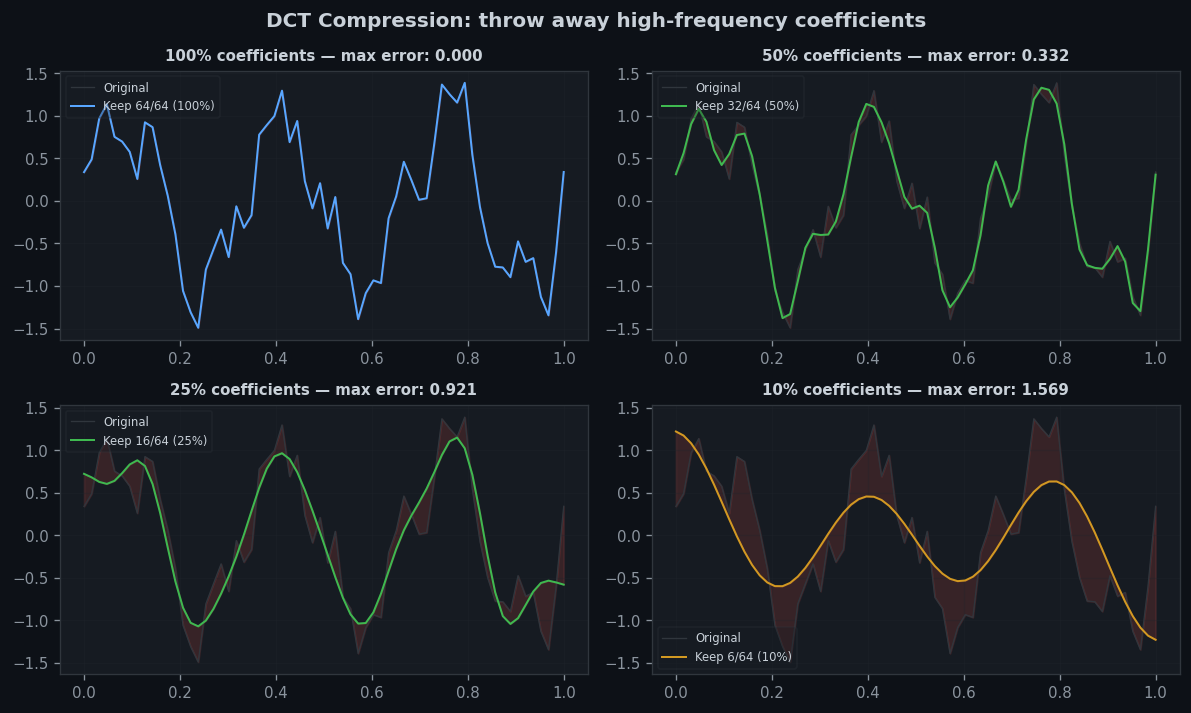

In [12]:
# ── 4a  DCT compression ───────────────────────────────────────
def dct_1d(x):
    N = len(x)
    n = np.arange(N)
    C = np.zeros(N)
    for k in range(N):
        C[k] = np.sum(x * np.cos(np.pi * k * (2*n + 1) / (2*N)))
    return C

def idct_1d(C):
    N = len(C)
    n = np.arange(N)
    x = np.zeros(N)
    for k in range(N):
        scale = 0.5 if k == 0 else 1.0
        x += scale * C[k] * np.cos(np.pi * k * (2*n + 1) / (2*N))
    return x * 2 / N

# Generate a signal that mimics a row of pixel intensities
np.random.seed(7)
N = 64
t = np.linspace(0, 1, N)
original = (np.sin(2*np.pi*3*t) + 0.4*np.sin(2*np.pi*8*t)
            + 0.2*np.random.randn(N))  # slight texture

C = dct_1d(original)
keep_fractions = [1.0, 0.5, 0.25, 0.10]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, frac in zip(axes.flat, keep_fractions):
    keep = int(N * frac)
    C_trunc = C.copy()
    C_trunc[keep:] = 0
    recon = idct_1d(C_trunc)
    error = np.max(np.abs(original - recon))

    ax.plot(t, original, color="#30363d", linewidth=0.8, label="Original")
    ax.plot(t, recon, color=CYAN if frac == 1 else GREEN if frac > 0.2 else ORANGE,
            linewidth=1.2, label=f"Keep {keep}/{N} ({frac*100:.0f}%)")
    ax.fill_between(t, original, recon, alpha=0.15, color=RED)
    ax.set_title(f"{frac*100:.0f}% coefficients — max error: {error:.3f}",
                 fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("DCT Compression: throw away high-frequency coefficients",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 4b — Spectrogram: seeing frequency change over time

A spectrogram chops the signal into short windows and FFTs each one, building a time-frequency heatmap. Here's a chirp (rising frequency) to show it in action.

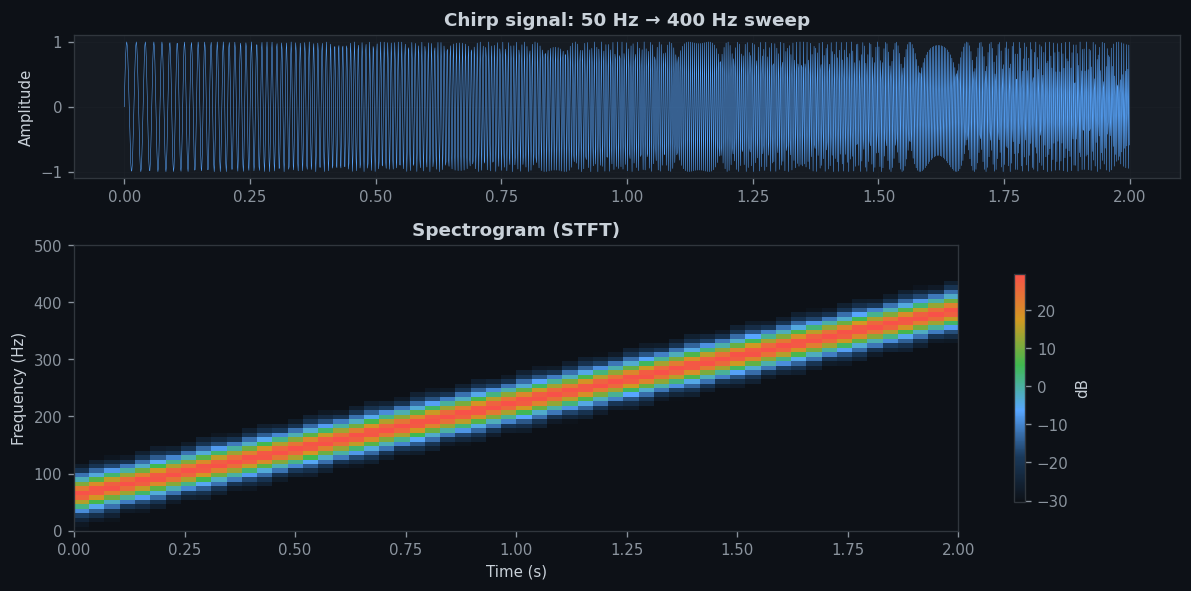

In [13]:
# ── 4b  Spectrogram ───────────────────────────────────────────
fs = 1000
duration = 2.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
# Chirp: frequency sweeps from 50 Hz to 400 Hz
chirp = np.sin(2 * np.pi * (50 * t + 175 * t**2 / duration))

# Build spectrogram manually (matching the scripts' approach)
window_size = 128
hop = 32
n_windows = (len(chirp) - window_size) // hop
spec = np.zeros((window_size // 2, n_windows))
hann_win = 0.5 * (1 - np.cos(2 * np.pi * np.arange(window_size) / window_size))

for i in range(n_windows):
    start = i * hop
    chunk = chirp[start:start + window_size] * hann_win
    X = np.fft.fft(chunk)
    spec[:, i] = np.abs(X[:window_size // 2])

spec_db = 20 * np.log10(spec + 1e-10)

fig, (ax_wave, ax_spec) = plt.subplots(2, 1, figsize=(10, 5),
                                        gridspec_kw={"height_ratios": [1, 2]})

ax_wave.plot(t, chirp, color=CYAN, linewidth=0.3)
ax_wave.set_ylabel("Amplitude")
ax_wave.set_title("Chirp signal: 50 Hz → 400 Hz sweep")
ax_wave.grid(True, alpha=0.3)

# Custom colormap
cmap = LinearSegmentedColormap.from_list("wave",
    ["#0d1117", "#1a3a5c", "#58a6ff", "#3fb950", "#d29922", "#f85149"])

extent = [0, duration, 0, fs / 2]
im = ax_spec.imshow(spec_db, aspect="auto", origin="lower", extent=extent,
                     cmap=cmap, vmin=spec_db.max() - 60, vmax=spec_db.max())
ax_spec.set_ylabel("Frequency (Hz)")
ax_spec.set_xlabel("Time (s)")
ax_spec.set_ylim(0, 500)
ax_spec.set_title("Spectrogram (STFT)")
fig.colorbar(im, ax=ax_spec, label="dB", shrink=0.8)

plt.tight_layout()
plt.show()

### 4c — FIR lowpass filter: cutting high frequencies

A sinc-windowed FIR filter passes frequencies below the cutoff and blocks everything above.

/tmp/ipykernel_2622/1190788559.py:9: RuntimeWarning: invalid value encountered in divide
  np.sin(2*np.pi*fc*shifted) / (np.pi*shifted))


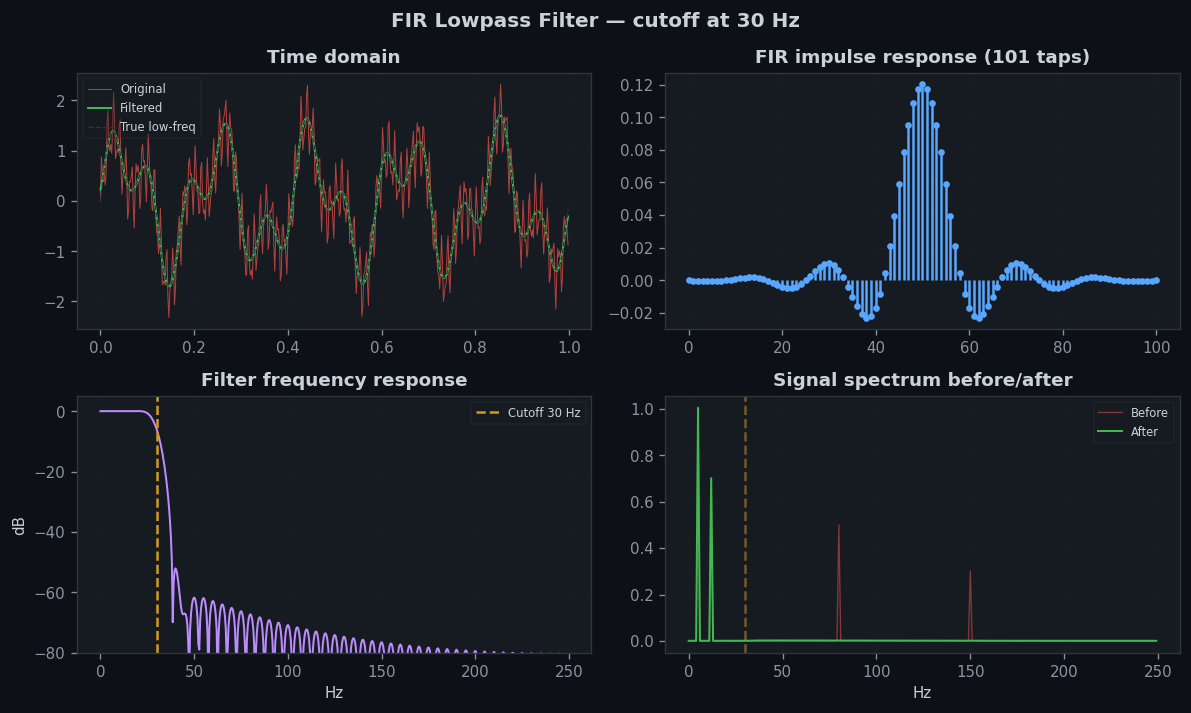

In [14]:
# ── 4c  FIR lowpass filter ────────────────────────────────────
def design_fir_lowpass(cutoff_hz, sample_rate, num_taps=51):
    fc = cutoff_hz / sample_rate
    n = np.arange(num_taps)
    mid = (num_taps - 1) / 2
    shifted = n - mid
    # Safe sinc
    h = np.where(np.abs(shifted) < 1e-10, 2*fc,
                 np.sin(2*np.pi*fc*shifted) / (np.pi*shifted))
    # Hamming window
    h *= 0.54 - 0.46 * np.cos(2*np.pi*n / (num_taps-1))
    return h / np.sum(h)

fs = 500
t = np.linspace(0, 1, fs, endpoint=False)
low = np.sin(2*np.pi*5*t) + 0.7*np.sin(2*np.pi*12*t)
high = 0.5*np.sin(2*np.pi*80*t) + 0.3*np.sin(2*np.pi*150*t)
signal = low + high

cutoff = 30
h = design_fir_lowpass(cutoff, fs, num_taps=101)
filtered = np.convolve(signal, h, mode="same")

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Time domain
axes[0][0].plot(t, signal, color=RED, linewidth=0.6, alpha=0.7, label="Original")
axes[0][0].plot(t, filtered, color=GREEN, linewidth=1.2, label="Filtered")
axes[0][0].plot(t, low, color="#30363d", linewidth=0.8, linestyle="--",
                label="True low-freq")
axes[0][0].set_title("Time domain")
axes[0][0].legend(fontsize=7)
axes[0][0].grid(True, alpha=0.3)

# Filter impulse response
axes[0][1].stem(np.arange(len(h)), h, linefmt=CYAN, markerfmt=".", basefmt=" ")
axes[0][1].set_title(f"FIR impulse response ({len(h)} taps)")
axes[0][1].grid(True, alpha=0.3)

# Frequency response of filter
H = np.fft.fft(h, 1024)
f_axis = np.fft.fftfreq(1024, 1/fs)
pos = f_axis >= 0
axes[1][0].plot(f_axis[pos], 20*np.log10(np.abs(H[pos]) + 1e-10),
                color=PURPLE, linewidth=1.2)
axes[1][0].axvline(cutoff, color=ORANGE, linestyle="--", label=f"Cutoff {cutoff} Hz")
axes[1][0].set_ylim(-80, 5)
axes[1][0].set_xlabel("Hz")
axes[1][0].set_ylabel("dB")
axes[1][0].set_title("Filter frequency response")
axes[1][0].legend(fontsize=7)
axes[1][0].grid(True, alpha=0.3)

# Before/after spectrum
X_before = np.fft.fft(signal)
X_after = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(signal), 1/fs)
pos_s = freqs >= 0
axes[1][1].plot(freqs[pos_s], np.abs(X_before[pos_s])/len(signal)*2,
                color=RED, alpha=0.5, linewidth=0.8, label="Before")
axes[1][1].plot(freqs[pos_s], np.abs(X_after[pos_s])/len(signal)*2,
                color=GREEN, linewidth=1.2, label="After")
axes[1][1].axvline(cutoff, color=ORANGE, linestyle="--", alpha=0.5)
axes[1][1].set_xlabel("Hz")
axes[1][1].set_title("Signal spectrum before/after")
axes[1][1].legend(fontsize=7)
axes[1][1].grid(True, alpha=0.3)

fig.suptitle(f"FIR Lowpass Filter — cutoff at {cutoff} Hz",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5 · Quantum Wave Functions
*Companion to `quantum_wave_functions.py`*

### 5a — Bloch sphere & quantum gates

A qubit is $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ where $|\alpha|^2 + |\beta|^2 = 1$. Below: probability evolution through Grover's algorithm (amplitude amplification), and a visual of quantum gate effects.

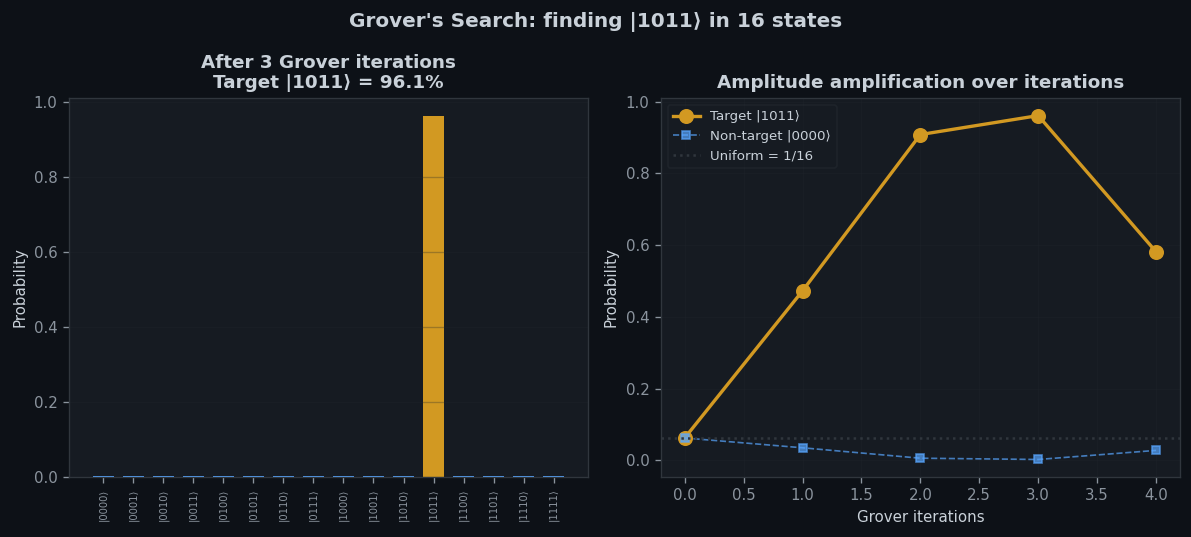

In [15]:
# ── 5a  Grover's algorithm — amplitude amplification ──────────
H = np.array([[1, 1], [1, -1]]) / math.sqrt(2)

class QubitRegister:
    def __init__(self, n):
        self.n = n
        self.state = np.zeros(2**n, dtype=complex)
        self.state[0] = 1.0

    def apply_single(self, gate, target):
        N = 2 ** self.n
        new_state = np.zeros(N, dtype=complex)
        for i in range(N):
            bit = (i >> target) & 1
            for g_row in range(2):
                if gate[g_row, bit] != 0:
                    j = i ^ ((bit ^ g_row) << target)
                    new_state[j] += gate[g_row, bit] * self.state[i]
        self.state = new_state

n_qubits = 4
N = 2 ** n_qubits
target = 11  # |1011⟩
optimal_iters = max(1, round(math.pi/4 * math.sqrt(N)))

# Track probability at each Grover iteration
prob_history = []

for max_iter in range(optimal_iters + 2):
    qr = QubitRegister(n_qubits)
    for q in range(n_qubits):
        qr.apply_single(H, q)
    for _ in range(max_iter):
        qr.state[target] *= -1
        mean_amp = np.mean(qr.state)
        qr.state = 2 * mean_amp - qr.state
    probs = np.abs(qr.state)**2
    prob_history.append(probs.copy())

fig, (ax_bar, ax_evo) = plt.subplots(1, 2, figsize=(10, 4.5))

# Final state bar chart
final_probs = prob_history[optimal_iters]
colors_bar = [ORANGE if i == target else CYAN for i in range(N)]
ax_bar.bar(range(N), final_probs, color=colors_bar, width=0.7)
ax_bar.set_xticks(range(N))
ax_bar.set_xticklabels([f"|{i:04b}⟩" for i in range(N)],
                        rotation=90, fontsize=6)
ax_bar.set_ylabel("Probability")
ax_bar.set_title(f"After {optimal_iters} Grover iterations\nTarget |{target:04b}⟩ = {final_probs[target]:.1%}")
ax_bar.grid(True, alpha=0.3, axis="y")

# Probability evolution
iters_range = range(len(prob_history))
target_probs = [p[target] for p in prob_history]
other_probs = [p[0] for p in prob_history]  # representative non-target
ax_evo.plot(list(iters_range), target_probs, "o-", color=ORANGE,
            linewidth=2, markersize=8, label=f"Target |{target:04b}⟩")
ax_evo.plot(list(iters_range), other_probs, "s--", color=CYAN,
            linewidth=1, markersize=5, alpha=0.7, label="Non-target |0000⟩")
ax_evo.axhline(1/N, color="#30363d", linestyle=":", label=f"Uniform = 1/{N}")
ax_evo.set_xlabel("Grover iterations")
ax_evo.set_ylabel("Probability")
ax_evo.set_title("Amplitude amplification over iterations")
ax_evo.legend(fontsize=8)
ax_evo.grid(True, alpha=0.3)

fig.suptitle("Grover's Search: finding |1011⟩ in 16 states",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 5b — Entanglement & the Quantum Fourier Transform

**Left:** A Bell state $|\Phi^+\rangle = \frac{1}{\sqrt 2}(|00\rangle + |11\rangle)$ — perfectly correlated, only two outcomes possible.
**Right:** The QFT maps computational basis states to evenly-spaced phase states — the quantum analog of the DFT.

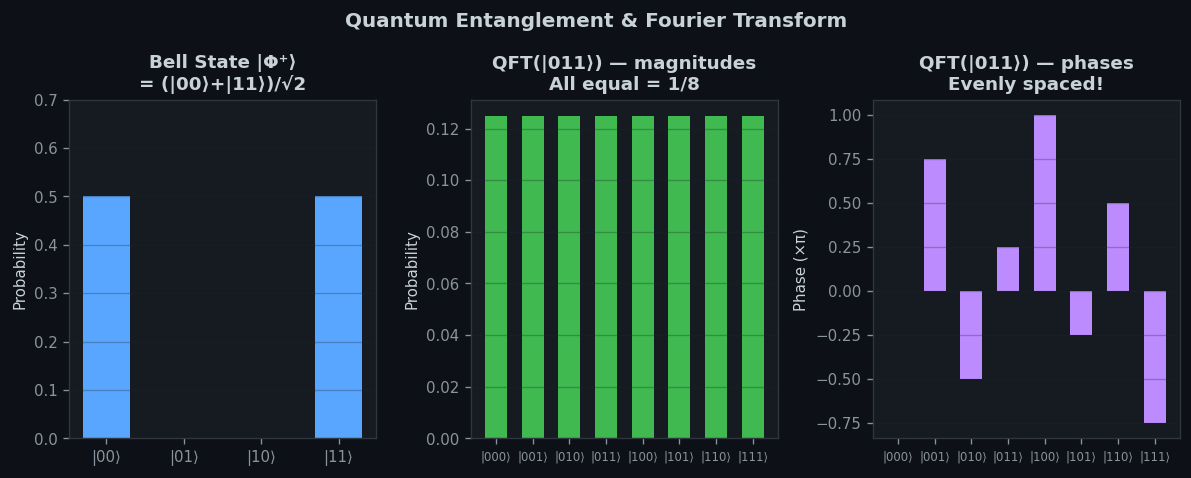

In [16]:
# ── 5b  Entanglement & QFT ────────────────────────────────────
CNOT = np.array([[1,0,0,0],
                 [0,1,0,0],
                 [0,0,0,1],
                 [0,0,1,0]], dtype=complex)

# Build Bell state: H on q0, CNOT(q0, q1)
state = np.zeros(4, dtype=complex)
state[0] = 1.0
# Apply H to qubit 0 (in 2-qubit space)
H2 = np.kron(H, np.eye(2))
state = H2 @ state
# Apply CNOT
state = CNOT @ state
bell_probs = np.abs(state)**2

# QFT matrix for 3 qubits
n_q = 3
N_q = 2**n_q
omega = np.exp(2j * np.pi / N_q)
QFT_matrix = np.array([[omega**(j*k) for k in range(N_q)]
                         for j in range(N_q)]) / math.sqrt(N_q)

# Apply QFT to |3⟩ = |011⟩
input_state = np.zeros(N_q, dtype=complex)
input_state[3] = 1.0
qft_output = QFT_matrix @ input_state

fig, (ax_bell, ax_qft_mag, ax_qft_phase) = plt.subplots(1, 3, figsize=(10, 4))

# Bell state
labels_2q = ["|00⟩", "|01⟩", "|10⟩", "|11⟩"]
bars = ax_bell.bar(range(4), bell_probs,
                    color=[CYAN if p > 0.01 else "#30363d" for p in bell_probs],
                    width=0.6)
ax_bell.set_xticks(range(4))
ax_bell.set_xticklabels(labels_2q)
ax_bell.set_ylabel("Probability")
ax_bell.set_title("Bell State |Φ⁺⟩\n= (|00⟩+|11⟩)/√2")
ax_bell.set_ylim(0, 0.7)
ax_bell.grid(True, alpha=0.3, axis="y")

# QFT magnitude
labels_3q = [f"|{i:03b}⟩" for i in range(N_q)]
ax_qft_mag.bar(range(N_q), np.abs(qft_output)**2,
               color=GREEN, width=0.6)
ax_qft_mag.set_xticks(range(N_q))
ax_qft_mag.set_xticklabels(labels_3q, fontsize=7)
ax_qft_mag.set_ylabel("Probability")
ax_qft_mag.set_title(f"QFT(|011⟩) — magnitudes\nAll equal = 1/{N_q}")
ax_qft_mag.grid(True, alpha=0.3, axis="y")

# QFT phases
phases = np.angle(qft_output)
bars_p = ax_qft_phase.bar(range(N_q), phases / np.pi,
                            color=PURPLE, width=0.6)
ax_qft_phase.set_xticks(range(N_q))
ax_qft_phase.set_xticklabels(labels_3q, fontsize=7)
ax_qft_phase.set_ylabel("Phase (×π)")
ax_qft_phase.set_title("QFT(|011⟩) — phases\nEvenly spaced!")
ax_qft_phase.grid(True, alpha=0.3, axis="y")

fig.suptitle("Quantum Entanglement & Fourier Transform",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6 · The Full Spectrum — Capstone Pipeline
*Companion to `the_full_spectrum.py`*

All six techniques woven into a single 8-stage pipeline:

**Generate → Sample → FFT analyze → DCT compress → Add noise → Wavelet denoise → Sinc reconstruct → Verify**

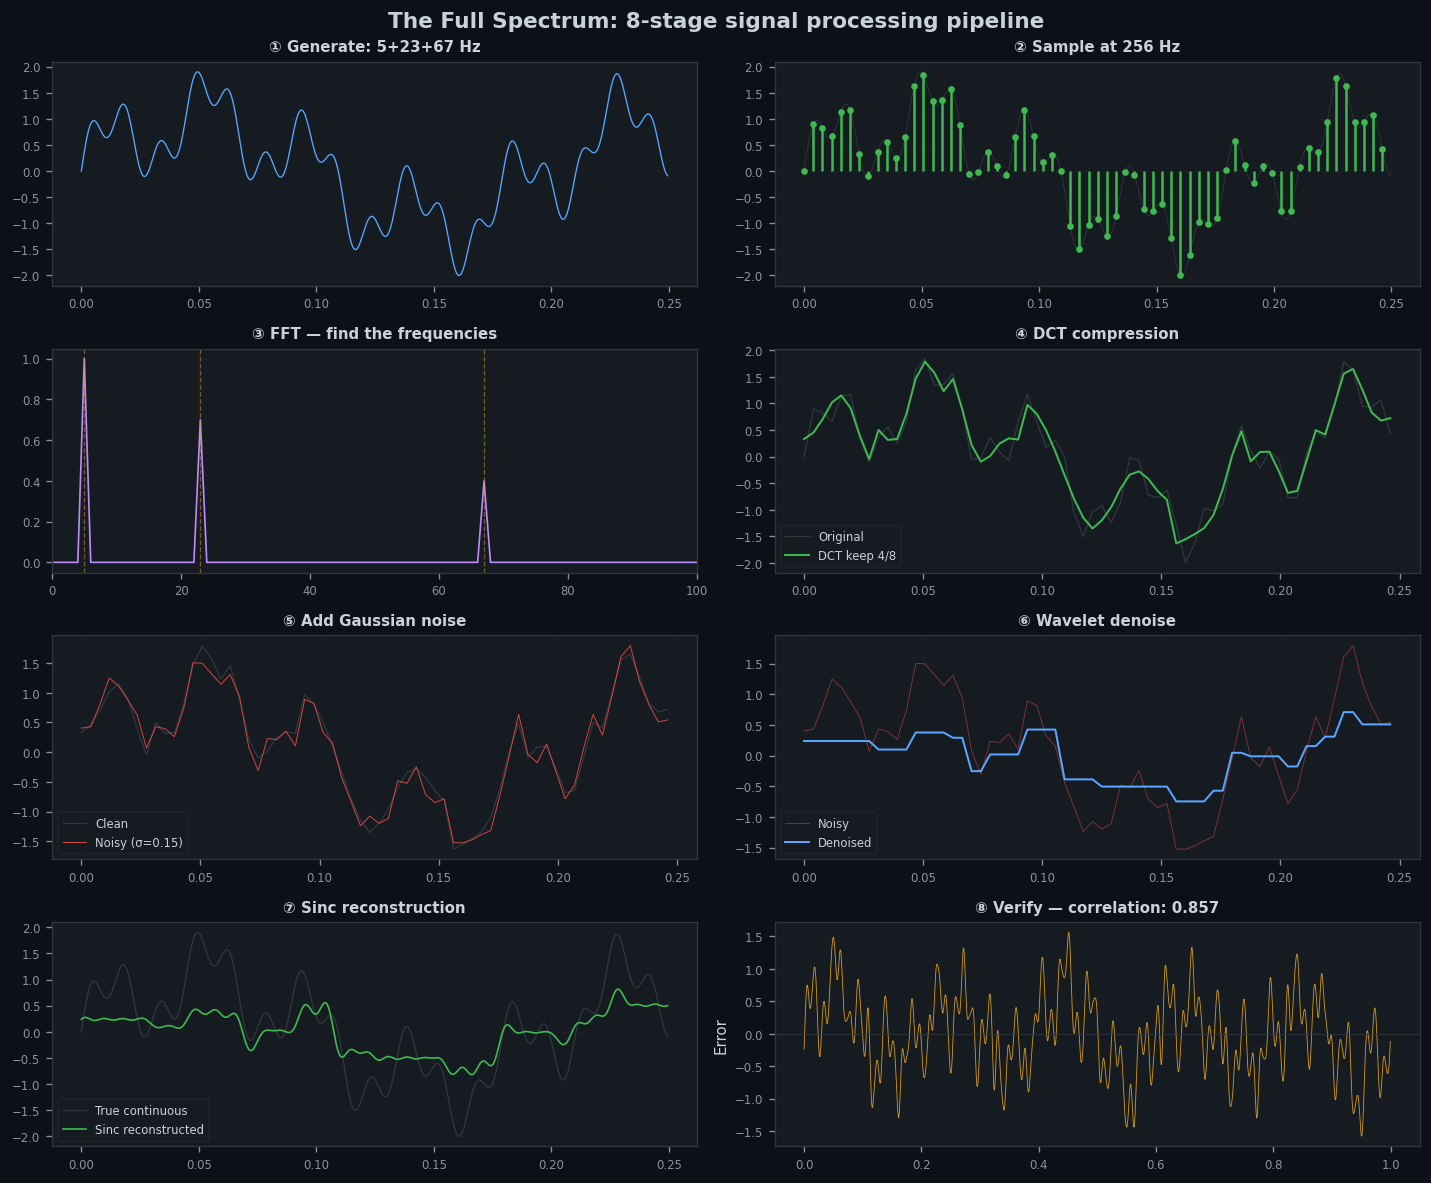

In [17]:
# ── 6  Full pipeline capstone ─────────────────────────────────

# === Stage 1: Generate ===
original_rate = 2000
duration = 1.0
t_orig = np.linspace(0, duration, int(original_rate * duration), endpoint=False)
freqs_true = [(5, 1.0), (23, 0.7), (67, 0.4)]
original = sum(a * np.sin(2*np.pi*f*t_orig) for f, a in freqs_true)

# === Stage 2: Sample at 256 Hz ===
sample_rate = 256
n_samples = int(sample_rate * duration)
t_sampled = np.linspace(0, duration, n_samples, endpoint=False)
sampled = sum(a * np.sin(2*np.pi*f*t_sampled) for f, a in freqs_true)

# === Stage 3: FFT analysis ===
X = np.fft.fft(sampled)
fft_freqs = np.fft.fftfreq(n_samples, 1/sample_rate)
fft_mag = np.abs(X) / n_samples * 2

# === Stage 4: DCT compression ===
block_size = 8
n_blocks = len(sampled) // block_size
compressed = np.zeros_like(sampled)
keep = 4  # keep 4 of 8 coefficients
for b in range(n_blocks):
    block = sampled[b*block_size:(b+1)*block_size]
    C = dct_1d(block)
    C[keep:] = 0
    compressed[b*block_size:(b+1)*block_size] = idct_1d(C)

# === Stage 5: Add noise ===
np.random.seed(42)
noise_level = 0.15
noisy = compressed + np.random.randn(len(compressed)) * noise_level

# === Stage 6: Wavelet denoise ===
pad_len = 2**int(np.ceil(np.log2(len(noisy))))
padded = np.zeros(pad_len)
padded[:len(noisy)] = noisy
approx_cap, details_cap = haar_decompose(padded)
denoised_dets = []
for i, d in enumerate(details_cap):
    sigma = noise_level
    thr = 0.8 * sigma * math.sqrt(2 * math.log(max(len(d), 2)))
    denoised_dets.append(soft_threshold(d, thr))
denoised_padded = haar_reconstruct(approx_cap, denoised_dets)
denoised = denoised_padded[:len(noisy)]

# === Stage 7: Sinc reconstruction ===
def sinc_recon(samples, sr, n_out):
    T = 1.0 / sr
    t_out = np.linspace(0, len(samples)*T, n_out, endpoint=False)
    result = np.zeros(n_out)
    for n, s in enumerate(samples):
        shifted = (t_out - n*T) / T
        pi_s = np.pi * shifted
        sinc = np.ones_like(shifted)
        nz = np.abs(shifted) > 1e-10
        sinc[nz] = np.sin(pi_s[nz]) / pi_s[nz]
        result += s * sinc
    return result, t_out

reconstructed, t_recon = sinc_recon(denoised, sample_rate, len(t_orig))

# === PLOT all 8 stages ===
fig, axes = plt.subplots(4, 2, figsize=(12, 10))

# 1: Generate
axes[0][0].plot(t_orig[:500], original[:500], color=CYAN, linewidth=0.8)
axes[0][0].set_title("① Generate: 5+23+67 Hz", fontsize=9)
axes[0][0].grid(True, alpha=0.3)

# 2: Sample
axes[0][1].plot(t_orig[:500], original[:500], color="#30363d", linewidth=0.5)
axes[0][1].stem(t_sampled[:64], sampled[:64], linefmt=GREEN,
                markerfmt=".", basefmt=" ")
axes[0][1].set_title(f"② Sample at {sample_rate} Hz", fontsize=9)
axes[0][1].grid(True, alpha=0.3)

# 3: FFT
pos_f = fft_freqs >= 0
axes[1][0].plot(fft_freqs[pos_f], fft_mag[pos_f], color=PURPLE, linewidth=1)
for f, a in freqs_true:
    axes[1][0].axvline(f, color=ORANGE, linestyle="--", alpha=0.5, linewidth=0.8)
axes[1][0].set_title("③ FFT — find the frequencies", fontsize=9)
axes[1][0].set_xlim(0, 100)
axes[1][0].grid(True, alpha=0.3)

# 4: DCT compress
axes[1][1].plot(t_sampled[:64], sampled[:64], color="#30363d",
                linewidth=0.8, label="Original")
axes[1][1].plot(t_sampled[:64], compressed[:64], color=GREEN,
                linewidth=1.2, label=f"DCT keep {keep}/{block_size}")
axes[1][1].set_title("④ DCT compression", fontsize=9)
axes[1][1].legend(fontsize=7)
axes[1][1].grid(True, alpha=0.3)

# 5: Noise
axes[2][0].plot(t_sampled[:64], compressed[:64], color="#30363d",
                linewidth=0.8, label="Clean")
axes[2][0].plot(t_sampled[:64], noisy[:64], color=RED,
                linewidth=0.6, alpha=0.8, label=f"Noisy (σ={noise_level})")
axes[2][0].set_title("⑤ Add Gaussian noise", fontsize=9)
axes[2][0].legend(fontsize=7)
axes[2][0].grid(True, alpha=0.3)

# 6: Denoise
axes[2][1].plot(t_sampled[:64], noisy[:64], color=RED,
                linewidth=0.5, alpha=0.5, label="Noisy")
axes[2][1].plot(t_sampled[:64], denoised[:64], color=CYAN,
                linewidth=1.2, label="Denoised")
axes[2][1].set_title("⑥ Wavelet denoise", fontsize=9)
axes[2][1].legend(fontsize=7)
axes[2][1].grid(True, alpha=0.3)

# 7: Reconstruct
axes[3][0].plot(t_orig[:500], original[:500], color="#30363d",
                linewidth=0.8, label="True continuous")
axes[3][0].plot(t_recon[:500], reconstructed[:500], color=GREEN,
                linewidth=1, label="Sinc reconstructed")
axes[3][0].set_title("⑦ Sinc reconstruction", fontsize=9)
axes[3][0].legend(fontsize=7)
axes[3][0].grid(True, alpha=0.3)

# 8: Verify
corr = np.corrcoef(original[:len(reconstructed)], reconstructed)[0, 1]
error = original[:len(reconstructed)] - reconstructed
axes[3][1].plot(t_orig, error[:len(t_orig)], color=ORANGE, linewidth=0.5)
axes[3][1].axhline(0, color="#30363d", linewidth=0.5)
axes[3][1].set_title(f"⑧ Verify — correlation: {corr:.3f}", fontsize=9)
axes[3][1].set_ylabel("Error")
axes[3][1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.tick_params(labelsize=7)

fig.suptitle("The Full Spectrum: 8-stage signal processing pipeline",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## What you just saw

| Stage | Technique | Section |
|-------|-----------|---------|
| Superposition & sampling | Nyquist, aliasing, quantization | §1 |
| Fourier Transform | Euler's formula, DFT, windowing | §2 |
| Wavelets | Uncertainty principle, Haar MRA, denoising | §3 |
| Practical applications | DCT/JPEG, spectrogram, FIR filters | §4 |
| Quantum computing | Grover's search, entanglement, QFT | §5 |
| Full pipeline | All techniques combined end-to-end | §6 |

Each plot corresponds to concepts explained in detail by the terminal scripts. Run those for the full narrative — this notebook is the visual companion.

*Built with numpy + matplotlib, no other dependencies.*